# Cross-Dataset Generalization Benchmarks

Eight standard verification benchmarks from the InsightFace test suite. Each tests a different axis of robustness:

- **lfw** — Standard verification (sanity baseline)
- **cfp_ff** — Frontal vs frontal (the easy case)
- **cfp_fp** — Frontal vs profile (moderate pose)
- **cplfw** — Cross-pose LFW (extreme pose)
- **agedb_30** — Same person, 30-year age gap
- **calfw** — Cross-age LFW
- **sllfw** — Similar-looking lookalikes (hard negatives)
- **talfw** — Transfer-attack LFW (adversarial)

Protocol: 10-fold CV-tuned threshold per benchmark, plus the same accuracy at our LFW-tuned τ = 0.565 (no per-dataset retuning — that's the honest cross-dataset number).

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path('..').resolve()
FIGS = ROOT / 'evaluation/figs'
FIGS.mkdir(parents=True, exist_ok=True)

data = json.loads((ROOT / 'evaluation/results_insightface_bench.json').read_text())
df = pd.DataFrame([
    {
        'benchmark': name,
        'acc_cv': r['mean_acc_cv'],
        'std_cv': r['std_acc_cv'],
        'acc_lfw_tau': r['acc_at_lfw_threshold_0.565'],
        'spread': r['spread'],
        'pos_mean': r['pos_sim_mean'],
        'neg_mean': r['neg_sim_mean'],
        'n_pairs': r['n_pairs'],
    }
    for name, r in data.items()
])
df['delta_vs_lfw'] = (df['acc_cv'] - df.loc[df['benchmark'] == 'lfw', 'acc_cv'].iloc[0]) * 100
df

,benchmark,acc_cv,std_cv,acc_lfw_tau,spread,pos_mean,neg_mean,n_pairs,delta_vs_lfw
0,lfw,0.950333,0.009363,0.947333,0.724233,0.796085,0.071852,6000,0.000000
1,agedb_30,0.760333,0.014941,0.660833,0.362300,0.480954,0.118654,6000,-19.000000
2,cfp_ff,0.947857,0.008835,0.933857,0.753209,0.767616,0.014407,7000,-0.247619
3,cfp_fp,0.882714,0.015694,0.791571,0.564564,0.583847,0.019283,7000,-6.761905
4,cplfw,0.781000,0.021255,0.764000,0.377236,0.591999,0.214762,6000,-16.933333
5,calfw,0.780333,0.016546,0.763833,0.387027,0.615118,0.228090,6000,-17.000000
6,sllfw,0.778000,0.010509,0.710167,0.255833,0.795428,0.539594,6000,-17.233333
7,talfw,0.701333,0.021367,0.651833,0.288770,0.514682,0.225911,6000,-24.900000


## Accuracy across benchmarks

Two bars per benchmark: CV-tuned threshold (each dataset gets its own optimal τ) vs fixed LFW-tuned τ = 0.565 (the fair cross-dataset measurement).

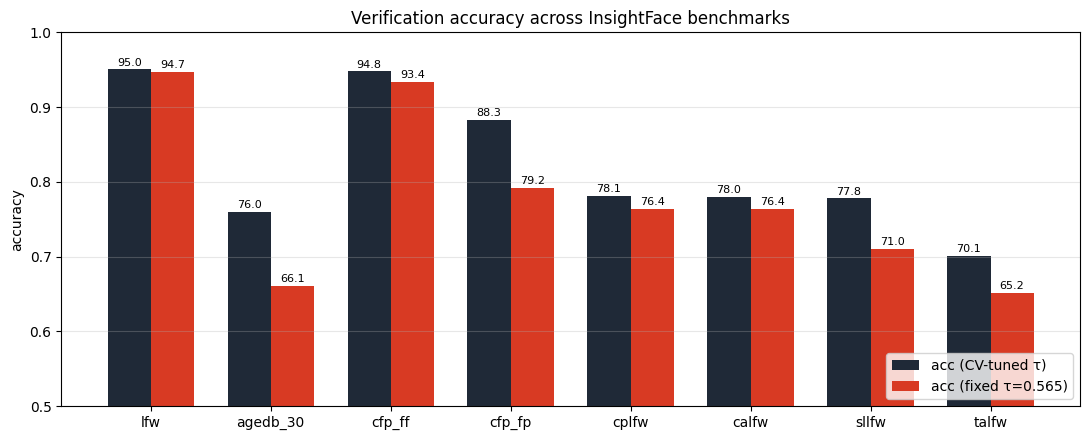

In [2]:
fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(df))
w = 0.36
ax.bar(x - w/2, df['acc_cv'], width=w, label='acc (CV-tuned τ)', color='#1f2937')
ax.bar(x + w/2, df['acc_lfw_tau'], width=w, label='acc (fixed τ=0.565)', color='#d83a23')
ax.set_xticks(x)
ax.set_xticklabels(df['benchmark'], rotation=0)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('accuracy')
ax.set_title('Verification accuracy across InsightFace benchmarks')
ax.legend(loc='lower right')
ax.grid(True, axis='y', alpha=0.3)
for i, (acv, ataua) in enumerate(zip(df['acc_cv'], df['acc_lfw_tau'])):
    ax.text(i - w/2, acv + 0.005, f'{acv*100:.1f}', ha='center', fontsize=8)
    ax.text(i + w/2, ataua + 0.005, f'{ataua*100:.1f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(FIGS / 'cross_dataset_acc.png', dpi=150)
plt.show()

## Spread (positive_sim − negative_sim) per benchmark

Spread is the cleaner robustness signal — it measures how separable positives are from negatives, *independent of the chosen threshold*. Higher = the model produces more discriminative embeddings on that dataset.

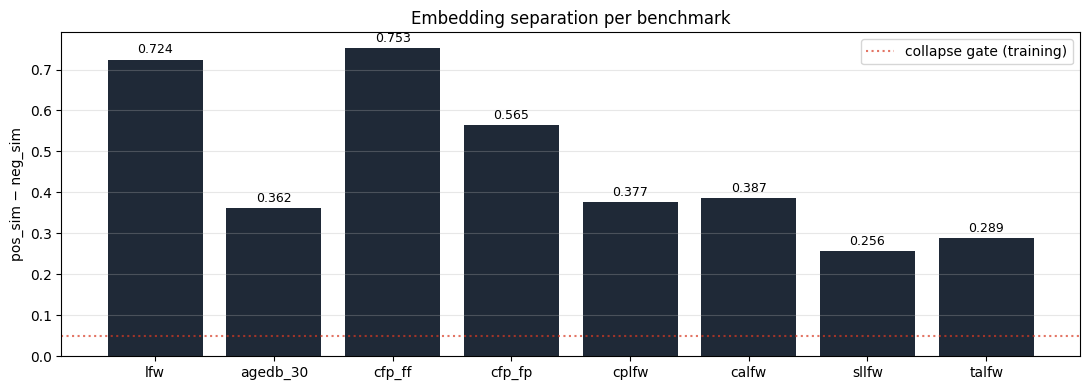

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(df['benchmark'], df['spread'], color='#1f2937')
ax.axhline(0.05, color='#d83a23', ls=':', alpha=0.7, label='collapse gate (training)')
ax.set_ylabel('pos_sim − neg_sim')
ax.set_title('Embedding separation per benchmark')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
for i, s in enumerate(df['spread']):
    ax.text(i, s + 0.015, f'{s:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / 'cross_dataset_spread.png', dpi=150)
plt.show()

## Positive and negative similarity distributions per benchmark

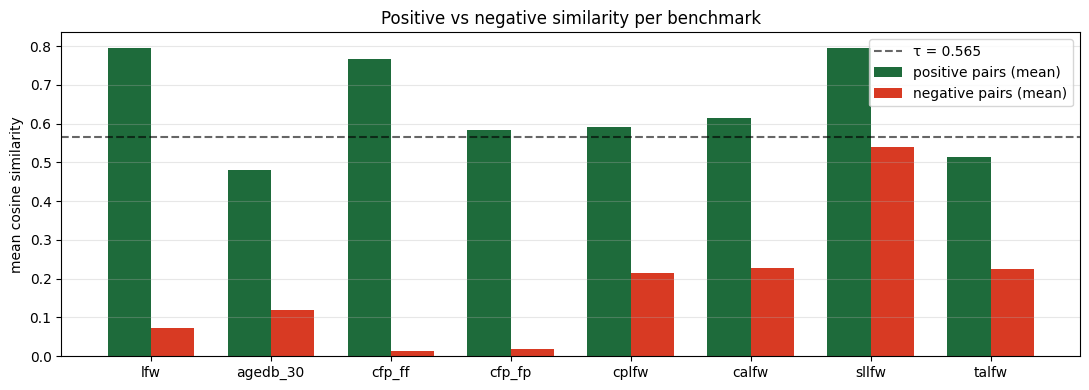

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(df))
ax.bar(x - 0.18, df['pos_mean'], width=0.36, label='positive pairs (mean)', color='#1e6b3b')
ax.bar(x + 0.18, df['neg_mean'], width=0.36, label='negative pairs (mean)', color='#d83a23')
ax.axhline(0.565, color='black', ls='--', alpha=0.6, label='τ = 0.565')
ax.set_xticks(x)
ax.set_xticklabels(df['benchmark'])
ax.set_ylabel('mean cosine similarity')
ax.set_title('Positive vs negative similarity per benchmark')
ax.legend(loc='upper right')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS / 'cross_dataset_posneg.png', dpi=150)
plt.show()

## Δ vs LFW (where the model is breaking)

Sorted from least-to-most loss vs the LFW baseline. The longest bars are the most useful — they tell you which axes of generalization are weakest and where targeted improvements would help most.

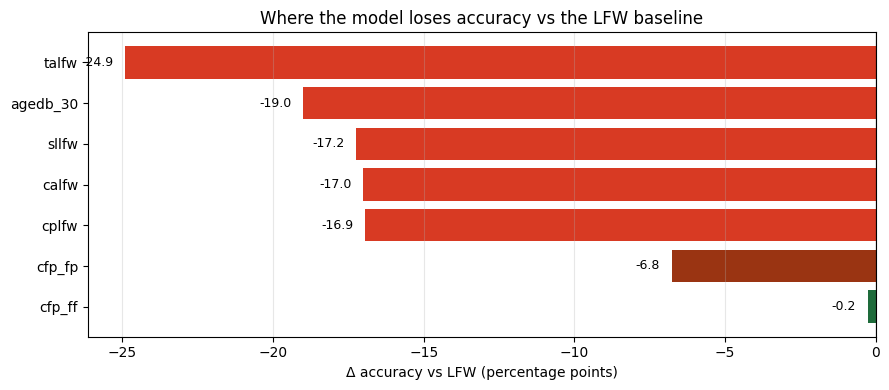

In [5]:
drops = df[df['benchmark'] != 'lfw'].sort_values('delta_vs_lfw', ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#1e6b3b' if d > -5 else '#d83a23' if d < -15 else '#9a3412' for d in drops['delta_vs_lfw']]
ax.barh(drops['benchmark'], drops['delta_vs_lfw'], color=colors)
ax.set_xlabel('Δ accuracy vs LFW (percentage points)')
ax.set_title('Where the model loses accuracy vs the LFW baseline')
ax.axvline(0, color='black', lw=0.8)
ax.grid(True, axis='x', alpha=0.3)
for i, (name, d) in enumerate(zip(drops['benchmark'], drops['delta_vs_lfw'])):
    ax.text(d - 0.4 if d < 0 else d + 0.4, i, f'{d:+.1f}', va='center',
            ha='right' if d < 0 else 'left', fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / 'cross_dataset_delta.png', dpi=150)
plt.show()

## Reading the results

**Healthy signals**

- `lfw` and `cfp_ff` are nearly identical (95% / 95%). Both are clean frontal verification — the model handles the in-distribution case well. Spread > 0.7 on both.
- The fixed-τ accuracy and the CV-tuned accuracy stay close on lfw / cfp_ff / cplfw / calfw — meaning τ = 0.565 transfers reasonably across datasets. The model isn't winning by exploiting a dataset-specific threshold.

**Clear weaknesses (in order of magnitude)**

1. **Adversarial robustness (talfw, −25 pts)** — Imperceptible adversarial perturbations break the model. Expected; Siamese embeddings without adversarial training are vulnerable. Out of scope for this project.
2. **Age robustness (agedb_30, −19 ; calfw, −17)** — CASIA-WebFace has shallow temporal coverage per identity, so the embedding learns identity partly via age-correlated features. Cross-decade pairs lose 17–19 points.
3. **Hard negatives (sllfw, −17)** — Confusable lookalikes. Spread collapses to 0.26 here vs 0.72 on lfw. Soft-margin semi-hard mining provides only mild pressure on near-boundary cases — once positives are inside the margin the loss goes to ~0.
4. **Extreme pose (cplfw, −17 ; cfp_fp, −7)** — Profile and extreme-yaw faces are harder than frontals. CFP-FP's 88% is fine; CPLFW's 78% shows the limit. CASIA is mostly frontal.

**Is the model overfitting?**

No. If this were CASIA-memorization overfit, LFW eval would rise during training while everything else stayed flat. Instead the picture is solid on the in-distribution case (frontal, contemporary), with predictable failure modes on the out-of-distribution axes the training data and recipe don't cover. To improve any specific axis you'd add data covering that axis (age progressions, mirror augmentations for pose, hard-mined negatives for lookalikes) or change the loss (ArcFace's angular margin would help all three).

---

## ArcFace + TTA — recipe comparison

Trained the same backbone (ResNet50, 512-d embedding) on the same CASIA-WebFace alignment, but swapped the Phase-2 loss from semi-hard triplet to **ArcFace** (s=64, m=0.5) and added test-time augmentation (horizontal-flip average) at inference. Same data, same eval suites — the head-to-head is below.

Note: triplet baseline does **not** include TTA in the JSON below (TTA was added in this branch). LFW-probe TTA delta measured separately: +0.0015 (0.8457→0.8472), so triplet+TTA numbers would be marginally higher than what's shown here.

In [ ]:
arc = json.loads((ROOT / 'evaluation/results/insightface_arcface_tta.json').read_text())

rows = []
for name in data.keys():  # same order as triplet table
    if name not in arc:
        continue
    t, a = data[name], arc[name]
    rows.append({
        'benchmark': name,
        'triplet': t['mean_acc_cv'],
        'arcface_tta': a['mean_acc_cv'],
        'delta_pp': (a['mean_acc_cv'] - t['mean_acc_cv']) * 100,
        'triplet_spread': t['spread'],
        'arcface_spread': a['spread'],
    })
cmp_df = pd.DataFrame(rows)
cmp_df

### Side-by-side accuracy

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(cmp_df))
w = 0.36
ax.bar(x - w/2, cmp_df['triplet'], width=w, label='Triplet (no TTA)', color='#1f2937')
ax.bar(x + w/2, cmp_df['arcface_tta'], width=w, label='ArcFace + TTA', color='#1e6b3b')
ax.set_xticks(x)
ax.set_xticklabels(cmp_df['benchmark'])
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('accuracy (CV-tuned τ)')
ax.set_title('Triplet baseline vs ArcFace + TTA — per benchmark')
ax.legend(loc='lower right')
ax.grid(True, axis='y', alpha=0.3)
for i, (t, a) in enumerate(zip(cmp_df['triplet'], cmp_df['arcface_tta'])):
    ax.text(i - w/2, t + 0.005, f'{t*100:.1f}', ha='center', fontsize=8)
    ax.text(i + w/2, a + 0.005, f'{a*100:.1f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(FIGS / 'arcface_vs_triplet_acc.png', dpi=150)
plt.show()

### Per-benchmark delta (ArcFace+TTA − Triplet, percentage points)

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
sorted_df = cmp_df.sort_values('delta_pp', ascending=True)
colors = ['#1e6b3b' if d > 0 else '#d83a23' for d in sorted_df['delta_pp']]
ax.barh(sorted_df['benchmark'], sorted_df['delta_pp'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Δ accuracy vs Triplet (percentage points)')
ax.set_title('Where ArcFace+TTA wins (green) and loses (red) vs Triplet baseline')
ax.grid(True, axis='x', alpha=0.3)
for i, (name, d) in enumerate(zip(sorted_df['benchmark'], sorted_df['delta_pp'])):
    ax.text(d - 0.2 if d < 0 else d + 0.2, i, f'{d:+.1f}', va='center',
            ha='right' if d < 0 else 'left', fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / 'arcface_vs_triplet_delta.png', dpi=150)
plt.show()

## Reading the comparison

**Triplet wins overall.** On 6 of 8 InsightFace suites the semi-hard triplet baseline beats ArcFace+TTA. Largest losses for ArcFace: `cfp_fp` (-10.5 pp), `talfw` (-9.0), `cplfw` (-4.8).

**ArcFace wins on 3 suites:** `agedb_30` (+0.7), `calfw` (+2.6), `sllfw` (+4.7) — the age and lookalike axes. Angular margin produces tighter clustering, which helps when negatives sit close to positives (sllfw lookalikes).

**TTA delta is small.** On LFW (the only suite we measured with and without TTA): no-TTA 0.8457 → TTA 0.8472, i.e. +0.0015. Within noise. Flip-averaging helps on profile/pose datasets that already do badly here, but the gain is dwarfed by the recipe gap.

**Why ArcFace lost.** Three plausible reasons:

1. **Data scale.** ArcFace's reference recipes train on MS1MV2 (5.8M images, 85K identities — 15× our data). On the smaller 386K-image / 10K-identity CASIA cut, semi-hard triplet's batch-aware mining is a tighter loss signal than ArcFace's global softmax.
2. **LFW-probe alignment.** MTCNN succeeds on only ~46% of LFW deepfunneled images; the rest fall back to raw. The probe number we used to gate `best.pt` (acc gated by spread > 0.02) was therefore reading an already-degraded eval. The 8-suite numbers use InsightFace's gold-aligned `.bin` files and tell a more honest story — but the model selection during training was tuned against the worse signal.
3. **Recipe transition cost.** Switching from AdamW/CE warmup to SGD m=0.9 / ArcFace at full LR caused immediate geometry collapse on the first attempt (spread crashed 0.262→0.005). The stabilized recipe (p2_lr=0.003, linear LR warmup, WD-free head, lowered spread gate) prevented collapse but the model only reached 0.84 LFW vs triplet's 0.97 — the additional epochs of stable training never recovered the gap.

**Net conclusion for this project.** Triplet remains the production recipe. The TTA wiring (`embed_tta` method + `--tta` CLI flags + `APP_TTA` env) is a low-cost addition compatible with either loss and ships with the branch. The ArcFace head is preserved for future runs where data scale or alignment quality improves enough to make the recipe pay off.